# LSTM 2-regime aware prediction (hard switching)

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler




In [2]:
# load data
df = pd.read_csv('../data/df_with_2regimes.csv')
df["date"] = pd.to_datetime(df["date"])
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3518 entries, 0 to 3517
Data columns (total 37 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   date                                        3518 non-null   datetime64[ns]
 1   log_return                                  3518 non-null   float64       
 2   realized_variance                           3518 non-null   float64       
 3   realized_volatility                         3518 non-null   float64       
 4   gtrend_pct_change                           3518 non-null   float64       
 5   blockchain_diff_log_n_transactions          3518 non-null   float64       
 6   blockchain_diff_log_transaction_fee_usd     3518 non-null   float64       
 7   blockchain_diff_log_n_unique_addresses      3518 non-null   float64       
 8   blockchain_diff_log_transaction_volume_usd  3518 non-null   float64       
 9   log_volu

In [3]:
# check for na
df.isna().sum()

# drop na (first 29 days of data)
df = df.dropna()


# Train, evaluation and out of sample split

In [4]:
# split data into train, evaluation and out of sample test sets 70/15/15

train_size = int(len(df) * 0.7)
eval_size = int(len(df) * 0.15)
train_df = df.iloc[:train_size]

eval_df = df.iloc[train_size:train_size + eval_size]
test_df = df.iloc[train_size + eval_size:]
print(f"Train set: {len(train_df)} rows")
print(f"Evaluation set: {len(eval_df)} rows")
print(f"Test set: {len(test_df)} rows")


Train set: 2442 rows
Evaluation set: 523 rows
Test set: 524 rows


In [5]:
lstm_features = [
    "blockchain_diff_log_n_transactions",
    "blockchain_diff_log_transaction_fee_usd",
    "blockchain_diff_log_n_unique_addresses",
    "blockchain_diff_log_transaction_volume_usd",
    "hash-rate_chg", 
    "difficulty_chg", 
    "median-confirmation-time_chg", 
    "blockchain_log_mempool_count_chg"
    ]

garch_features = [] # to be added later 
    

X_train_lstm = train_df[lstm_features]
X_eval_lstm  = eval_df[lstm_features]
X_test_lstm  = test_df[lstm_features]

y_train_regime = train_df["regime_id"].shift(-1)  # shift by 1 to predict next day's regime
y_eval_regime  = eval_df["regime_id"]
y_test_regime  = test_df["regime_id"]

In [6]:
def create_sequences(df, feature_cols, target_col, lookback=30):
    X_seq, y_seq, dates = [], [], []

    values = df[feature_cols].values
    target = df[target_col].values
    date_vals = df["date"].values if "date" in df.columns else np.arange(len(df))

    for t in range(lookback - 1, len(df) - 1):
        X_seq.append(values[t - lookback + 1:t + 1])
        y_seq.append(target[t + 1])
        dates.append(date_vals[t + 1])

    return np.array(X_seq), np.array(y_seq), np.array(dates)

def create_rolling_scaled_sequences_range(
    df, feature_cols, target_col, lookback, scale_window, start_idx, end_idx, date_col=None
):
    X, y, dates = [], [], []

    first_valid_idx = max(start_idx, lookback, scale_window)

    for t in range(first_valid_idx, end_idx - 1):

        hist_window = df[feature_cols].iloc[t - scale_window:t]
        seq_window = df[feature_cols].iloc[t - lookback:t]

        target = df[target_col].iloc[t + 1]

        if hist_window.isnull().any().any():
            continue
        if seq_window.isnull().any().any():
            continue
        if pd.isna(target):
            continue

        scaler = StandardScaler()
        scaler.fit(hist_window)

        seq_scaled = scaler.transform(seq_window)

        X.append(seq_scaled)
        y.append(target)

        if date_col is not None:
            dates.append(df[date_col].iloc[t + 1])
        else:
            dates.append(t + 1)

    return np.array(X), np.array(y), dates

def scale_rolling(df_hist, feature_cols, lookback, scale_window=365):

    scaler_hist = df_hist[feature_cols].iloc[-min(scale_window, len(df_hist)):].copy()

    scaler = StandardScaler()
    scaler.fit(scaler_hist)

    seq_raw = df_hist[feature_cols].iloc[-lookback:].copy()

    seq_scaled = scaler.transform(seq_raw)

    return seq_scaled, scaler

def build_lstm_model(lookback, n_features, n_regimes=2, units=64, dropout=0.2, optimizer="adam"):
    model = Sequential([
        LSTM(units, input_shape=(lookback, n_features)),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(n_regimes, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from arch import arch_model

# Grid Search for hyperparameters

#### LSTM model

In [20]:
def rolling_regime_forecast(
    df_full,
    lstm_model,
    feature_cols,
    lookback,
    start_idx,
    end_idx,
    scale_window=365,
    date_col="date",
    target_col="regime_id"
):

    results = []

    for t in range(start_idx - 1, end_idx - 1):

        df_hist = df_full.iloc[:t+1].copy()

        if len(df_hist) < lookback:
            continue

        try:
            seq_scaled, _ = scale_rolling(
                df_hist,
                feature_cols=feature_cols,
                lookback=lookback,
                scale_window=scale_window
            )
        except Exception:
            continue

        X_input = np.expand_dims(seq_scaled, axis=0)

        pred_probs = lstm_model.predict(X_input, verbose=0)
        pred_regime = int(np.argmax(pred_probs))

        next_row = df_full.iloc[t+1]

        results.append({
            "date": next_row[date_col],
            "pred_regime": pred_regime,
            "pred_prob_0": pred_probs[0,0],
            "pred_prob_1": pred_probs[0,1]
        })

    return pd.DataFrame(results)

In [10]:
def rolling_lstm_garch_hard_eval(
    df_full,
    regime_forecast_df,
    start_idx,
    end_idx,
    return_col="log_return",
    realized_var_col="realized_variance",
    regime_col="regime_id",
    date_col="date",
    garch_p=1,
    garch_q=1,
    garch_vol="Garch",
    garch_dist="normal",
    rolling_window=365
):
    results = []

    regime_map = regime_forecast_df.set_index(date_col)

    for t in range(start_idx - 1, end_idx - 1):
        next_row = df_full.iloc[t + 1]
        next_date = next_row[date_col]

        if next_date not in regime_map.index:
            continue

        # 1 step rolling estimation window
        window_df = df_full.iloc[max(0, t - rolling_window + 1): t + 1].copy()
        regime_pred_row = regime_map.loc[next_date]

        low_returns = window_df.loc[window_df[regime_col] == 0, return_col]
        high_returns = window_df.loc[window_df[regime_col] == 1, return_col]

        garch_low = fit_garch_safe(
            low_returns,
            p=garch_p,
            q=garch_q,
            vol=garch_vol,
            dist=garch_dist
        )

        garch_high = fit_garch_safe(
            high_returns,
            p=garch_p,
            q=garch_q,
            vol=garch_vol,
            dist=garch_dist
        )

        var_low = one_step_var_forecast(garch_low)
        var_high = one_step_var_forecast(garch_high)

        pred_regime = int(regime_pred_row["pred_regime"])

        if pred_regime == 0:
            var_hard = var_low
        else:
            var_hard = var_high

        results.append({
            "date": next_date,
            "actual_var": next_row[realized_var_col],
            "true_regime": int(next_row[regime_col]),
            "pred_regime": pred_regime,
            "var_low": var_low,
            "var_high": var_high,
            "var_hard": var_hard
        })

    return pd.DataFrame(results)

### Garch model

In [12]:
min_grach_obs = 100

def fit_garch_safe(returns, p=1, q=1, vol="Garch", dist="normal"):
    returns = returns.dropna().astype(float)

    if len(returns) < min_grach_obs:
        return None

    try:
        am = arch_model(
            returns * 100.0,
            mean="constant", # change to constant
            vol=vol,
            p=p,
            q=q,
            dist=dist
        )
        res = am.fit(disp="off")
        return res
    except Exception:
        return None


def one_step_var_forecast(fitted_garch):
    if fitted_garch is None:
        return np.nan

    try:
        fcast = fitted_garch.forecast(horizon=1, reindex=False)
        var_100 = fcast.variance.values[-1, 0]
        return var_100 / (100.0 ** 2) # scale back 
    except Exception:
        return np.nan

### Metrics

In [13]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))


def qlike(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true > 0) & (y_pred > 0)
    if mask.sum() == 0:
        return np.nan

    yt = y_true[mask]
    yp = y_pred[mask]

    return np.mean(np.log(yp + eps) + yt / (yp + eps))

#### Model tuning

In [14]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [15]:
train_start_idx = 0
train_end_idx = train_size

eval_start_idx = train_size
eval_end_idx = train_size + eval_size

test_start_idx = eval_end_idx
test_end_idx = len(df)

In [16]:
from itertools import product

In [18]:
lstm_grid = {
    "lookback": [20, 30, 60],
    "units": [32, 64],
    "dropout": [0.0, 0.01, 0.1, 0.2],
    "batch_size": [32]
} 

garch_grid = {
    "vol": ["Garch"],
    "p": [1,2],
    "q": [1,2],
    "dist": ["t"]
}

param_grid = []
for lb, units, drop, bs, vol, p, q, dist in product(
    lstm_grid["lookback"],
    lstm_grid["units"],
    lstm_grid["dropout"],
    lstm_grid["batch_size"],
    garch_grid["vol"],
    garch_grid["p"],
    garch_grid["q"],
    garch_grid["dist"]
):
    param_grid.append({
        "lookback": lb,
        "units": units,
        "dropout": drop,
        "batch_size": bs,
        "garch_vol": vol,
        "garch_p": p,
        "garch_q": q,
        "garch_dist": dist
    })

print(f"Total candidates: {len(param_grid)}")

Total candidates: 96


In [21]:
tuning_results = []

for i, params in enumerate(param_grid, 1):
    print(f"\n[{i}/{len(param_grid)}] Testing params: {params}")

    lookback = params["lookback"]

  
    # Rolling-scaled sequence creation
    X_train_lstm, y_train_regime, _ = create_rolling_scaled_sequences_range(
        df=df,
        feature_cols=lstm_features,
        target_col="regime_id",
        lookback=lookback,
        scale_window=365,
        start_idx=train_start_idx,
        end_idx=train_end_idx,
        date_col="date"
    )

    X_eval_lstm, y_eval_regime, _ = create_rolling_scaled_sequences_range(
        df=df,
        feature_cols=lstm_features,
        target_col="regime_id",
        lookback=lookback,
        scale_window=365,
        start_idx=eval_start_idx,
        end_idx=eval_end_idx,
        date_col="date"
    )

    if len(X_train_lstm) == 0 or len(X_eval_lstm) == 0:
        print("Skipping: no sequences produced.")
        continue

    y_train_cat = to_categorical(y_train_regime, num_classes=2)
    y_eval_cat = to_categorical(y_eval_regime, num_classes=2)

    
    # Build and train LSTM

    model = build_lstm_model(
        lookback=lookback,
        n_features=len(lstm_features),
        n_regimes=2,
        units=params["units"],
        dropout=params["dropout"],
        optimizer="adam"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train_lstm,
        y_train_cat,
        validation_data=(X_eval_lstm, y_eval_cat),
        epochs=100,
        batch_size=params["batch_size"],
        callbacks=[early_stop],
        verbose=0
    )

    
    # rolling regime forecast on evaluation period
    
    eval_regime_roll = rolling_regime_forecast(
        df_full=df,
        lstm_model=model,
        feature_cols=lstm_features,
        lookback=lookback,
        start_idx=eval_start_idx,
        end_idx=eval_end_idx,
        scale_window=365,
        date_col="date",
        target_col="regime_id"
    )

    if eval_regime_roll.empty:
        print("Skipping: rolling regime forecast returned empty dataframe.")
        continue

    
    # Rolling hard-switch GARCH eval

    eval_stage2 = rolling_lstm_garch_hard_eval(
        df_full=df,
        regime_forecast_df=eval_regime_roll,
        start_idx=eval_start_idx,
        end_idx=eval_end_idx,
        return_col="log_return",
        realized_var_col="realized_variance",
        regime_col="regime_id",
        date_col="date",
        garch_p=params["garch_p"],
        garch_q=params["garch_q"],
        garch_vol=params["garch_vol"],
        garch_dist=params["garch_dist"],
        rolling_window=365
    )

    if eval_stage2.empty:
        print("Skipping: stage-2 evaluation returned empty dataframe.")
        continue

    score_rmse = rmse(eval_stage2["actual_var"], eval_stage2["var_hard"])
    score_qlike = qlike(eval_stage2["actual_var"], eval_stage2["var_hard"])

    tuning_results.append({
        **params,
        "eval_rmse": score_rmse,
        "eval_qlike": score_qlike,
        "n_eval_forecasts": len(eval_stage2)
    })

    print(f"Eval RMSE : {score_rmse:.6f}")
    print(f"Eval QLIKE: {score_qlike:.6f}")


[1/96] Testing params: {'lookback': 20, 'units': 32, 'dropout': 0.0, 'batch_size': 32, 'garch_vol': 'Garch', 'garch_p': 1, 'garch_q': 1, 'garch_dist': 't'}
Eval RMSE : 0.001018
Eval QLIKE: -5.998650

[2/96] Testing params: {'lookback': 20, 'units': 32, 'dropout': 0.0, 'batch_size': 32, 'garch_vol': 'Garch', 'garch_p': 1, 'garch_q': 2, 'garch_dist': 't'}
Eval RMSE : 0.001045
Eval QLIKE: -6.196172

[3/96] Testing params: {'lookback': 20, 'units': 32, 'dropout': 0.0, 'batch_size': 32, 'garch_vol': 'Garch', 'garch_p': 2, 'garch_q': 1, 'garch_dist': 't'}
Eval RMSE : 0.001039
Eval QLIKE: -6.171623

[4/96] Testing params: {'lookback': 20, 'units': 32, 'dropout': 0.0, 'batch_size': 32, 'garch_vol': 'Garch', 'garch_p': 2, 'garch_q': 2, 'garch_dist': 't'}
Eval RMSE : 0.001029
Eval QLIKE: -6.186919

[5/96] Testing params: {'lookback': 20, 'units': 32, 'dropout': 0.01, 'batch_size': 32, 'garch_vol': 'Garch', 'garch_p': 1, 'garch_q': 1, 'garch_dist': 't'}
Eval RMSE : 0.000992
Eval QLIKE: -6.136005

In [24]:
tuning_results

,lookback,units,dropout,batch_size,garch_vol,garch_p,garch_q,garch_dist,eval_rmse,eval_qlike,n_eval_forecasts
0,20,32,0.00,32,Garch,1,1,t,0.001018,-5.998650,523
1,20,32,0.00,32,Garch,1,2,t,0.001045,-6.196172,523
2,20,32,0.00,32,Garch,2,1,t,0.001039,-6.171623,523
3,20,32,0.00,32,Garch,2,2,t,0.001029,-6.186919,523
4,20,32,0.01,32,Garch,1,1,t,0.000992,-6.136005,523
...,...,...,...,...,...,...,...,...,...,...,...
91,60,64,0.10,32,Garch,2,2,t,0.000990,-6.101580,523
92,60,64,0.20,32,Garch,1,1,t,0.001073,-6.178915,523
93,60,64,0.20,32,Garch,1,2,t,0.001001,-6.037657,523
94,60,64,0.20,32,Garch,2,1,t,0.001016,-6.115293,523


In [23]:
tuning_results = pd.DataFrame(tuning_results)
print("\nTop 5 configs by QLIKE:")
print(tuning_results.sort_values("eval_qlike").head())

# export to csv
# tuning_results.to_csv("results/lstm_garch_tuning_results.csv", index=False)


Top 5 configs by QLIKE:
    lookback  units  dropout  batch_size garch_vol  garch_p  garch_q  \
13        20     32     0.20          32     Garch        1        2   
47        30     32     0.20          32     Garch        2        2   
69        60     32     0.01          32     Garch        1        2   
75        60     32     0.10          32     Garch        2        2   
5         20     32     0.01          32     Garch        1        2   

   garch_dist  eval_rmse  eval_qlike  n_eval_forecasts  
13          t   0.001041   -6.246627               523  
47          t   0.001025   -6.245651               523  
69          t   0.000999   -6.243670               523  
75          t   0.001041   -6.243428               523  
5           t   0.001024   -6.238846               523  


In [25]:
## final best paraters based on evaluation set
best_params = {
 'lookback': 20,
 'units': 32,
 'dropout': 0.2,
 'batch_size': 32,
 'garch_p': 1,
 'garch_q': 2,
 'garch_vol': 'Garch',
 'garch_dist': 't'
} 

train_eval_end_idx = eval_end_idx

X_train_final, y_train_final, _ = create_rolling_scaled_sequences_range(
    df=df,
    feature_cols=lstm_features,
    target_col="regime_id",
    lookback=best_params["lookback"],
    scale_window=365,
    start_idx=train_start_idx,
    end_idx=train_eval_end_idx,
    date_col="date"
)

y_train_cat = to_categorical(y_train_final, num_classes=2)

final_model = build_lstm_model(
    lookback=best_params["lookback"],
    n_features=len(lstm_features),
    n_regimes=2,
    units=best_params["units"],
    dropout=best_params["dropout"],
    optimizer="adam"
)

final_model.fit(
    X_train_final,
    y_train_cat,
    epochs=100,
    batch_size=best_params["batch_size"],
    verbose=0
)

In [26]:
test_regime_roll = rolling_regime_forecast(
    df_full=df,
    lstm_model=final_model,
    feature_cols=lstm_features,
    lookback=best_params["lookback"],
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    scale_window=365,
    date_col="date",
    target_col="regime_id"
)

test_stage2 = rolling_lstm_garch_hard_eval(
    df_full=df,
    regime_forecast_df=test_regime_roll,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    return_col="log_return",
    realized_var_col="realized_variance",
    regime_col="regime_id",
    date_col="date",
    garch_p=best_params["garch_p"],
    garch_q=best_params["garch_q"],
    garch_vol=best_params["garch_vol"],
    garch_dist=best_params["garch_dist"],
    rolling_window=365
)

test_rmse = rmse(test_stage2["actual_var"], test_stage2["var_hard"])
test_qlike = qlike(test_stage2["actual_var"], test_stage2["var_hard"])

print("Out-of-sample results:")
print("Test RMSE:", test_rmse)
print("Test QLIKE:", test_qlike)

Out-of-sample results:
Test RMSE: 0.0007259388567492733
Test QLIKE: -6.220717705682719


In [41]:
# merge and export test results
test_results = test_stage2.drop(columns=["pred_regime"]).merge(
    test_regime_roll[["date", "pred_regime"]],
    on="date",
    how="left"
)

# export to csv
test_results.to_csv("results/lstm_garch1_test_results.csv", index=False)

In [38]:
test_results.head()

,date,actual_var,true_regime,var_low,var_high,var_hard,pred_regime
0,2024-08-26,0.000184,0,0.000540,0.001671,0.000540,0
1,2024-08-27,0.001012,1,0.000314,0.001671,0.001671,1
2,2024-08-28,0.001237,1,0.000339,0.001178,0.001178,1
3,2024-08-29,0.000816,1,0.000339,0.001573,0.001573,1
4,2024-08-30,0.001032,1,0.000339,0.001091,0.000339,0


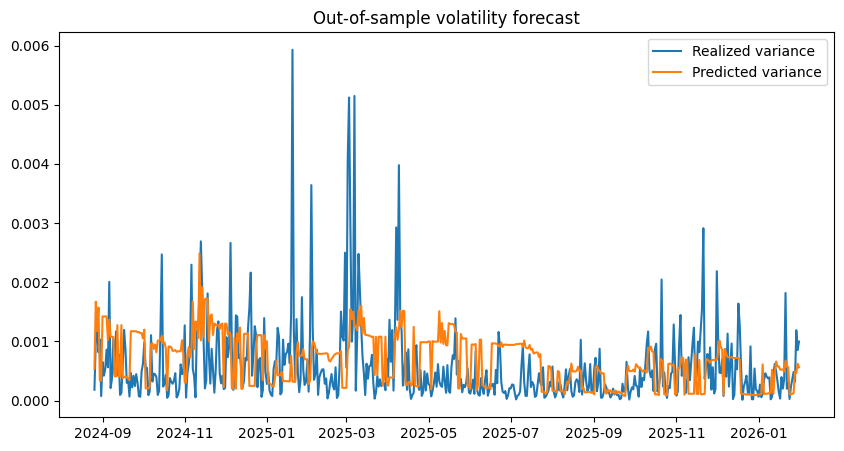

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test_stage2["date"], test_stage2["actual_var"], label="Realized variance")
plt.plot(test_stage2["date"], test_stage2["var_hard"], label="Predicted variance")
plt.legend()
plt.title("Out-of-sample volatility forecast")
plt.show()

In [36]:
test_stage2.head()

,date,actual_var,true_regime,pred_regime,var_low,var_high,var_hard
0,2024-08-26,0.000184,0,0,0.000540,0.001671,0.000540
1,2024-08-27,0.001012,1,1,0.000314,0.001671,0.001671
2,2024-08-28,0.001237,1,1,0.000339,0.001178,0.001178
3,2024-08-29,0.000816,1,1,0.000339,0.001573,0.001573
4,2024-08-30,0.001032,1,0,0.000339,0.001091,0.000339


In [32]:
# predicted regime vs actual regime confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(test_stage2["true_regime"], test_stage2["pred_regime"])
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(test_stage2["true_regime"], test_stage2["pred_regime"]))


Confusion Matrix:
[[ 93 147]
 [ 89 195]]

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.39      0.44       240
           1       0.57      0.69      0.62       284

    accuracy                           0.55       524
   macro avg       0.54      0.54      0.53       524
weighted avg       0.54      0.55      0.54       524

